In [1]:
import numpy as np
from dataclasses import dataclass
from typing import Dict, Tuple, Callable, List
from scipy import stats
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt

In [2]:
def tv(p, q):
    return 0.5 * np.sum(np.abs(p - q))

def hellinger(p, q):
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q))**2))

def kl(p, q):
    return np.sum(p * np.log(p / q))

def js(p, q):
    m = 0.5 * (p + q)
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)



In [3]:
def model_equal_prob_bins(dist, k: int) -> np.ndarray:
    qs = np.linspace(0.0, 1.0, k + 1)
    eps = 1e-10
    qs = np.clip(qs, eps, 1 - eps)
    edges = dist.ppf(qs)
    edges = np.maximum.accumulate(edges)
    return edges

def empirical_hist_probs(x: np.ndarray, edges: np.ndarray, alpha: float = 1e-6) -> np.ndarray:
    counts, _ = np.histogram(x, bins=edges)
    k = len(counts)
    n = len(x)
    p = (counts + alpha) / (n + k * alpha)
    return p

def model_bin_probs(dist, edges: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    cdf = dist.cdf(edges)
    q = np.diff(cdf)
    q = np.clip(q, eps, 1.0)
    q = q / q.sum()
    return q


In [4]:
def fit_normal(x):
    mu = np.mean(x)
    sigma = np.std(x, ddof=0)
    sigma = max(sigma, 1e-12)
    return stats.norm(loc=mu, scale=sigma)

def fit_expon(x):
    scale = np.mean(x)
    scale = max(scale, 1e-12)
    return stats.expon(loc=0.0, scale=scale)

def fit_gamma(x):
    a, loc, scale = stats.gamma.fit(x, floc=0.0)
    scale = max(scale, 1e-12)
    return stats.gamma(a=a, loc=0.0, scale=scale)

In [5]:
@dataclass
class DistanceResult:
    tv: float
    hellinger: float
    js: float
    kl_pq: float
    wasserstein1: float

def compute_distances(x: np.ndarray, dist, k_bins: int = 30,
                      smooth_alpha: float = 1e-6,
                      w_samples: int = None,
                      rng: np.random.Generator = None) -> DistanceResult:

    x = np.asarray(x)
    if rng is None:
        rng = np.random.default_rng(0)

    edges = model_equal_prob_bins(dist, k=k_bins)
    p_hat = empirical_hist_probs(x, edges, alpha=smooth_alpha)
    q = model_bin_probs(dist, edges)

    tv_val = tv(p_hat, q)
    h_val = hellinger(p_hat, q)
    js_val = js(p_hat, q)
    kl_val = kl(p_hat, q)

    if w_samples is None:
        w_samples = len(x)
    y = dist.rvs(size=w_samples, random_state=rng)
    w1_val = wasserstein_distance(x, y)

    return DistanceResult(tv=tv_val, hellinger=h_val, js=js_val, kl_pq=kl_val, wasserstein1=w1_val)


In [11]:
def bootstrap_distances(x: np.ndarray, fit_fn: Callable, B: int = 300,
                        k_bins: int = 30, smooth_alpha: float = 1e-6,
                        seed: int = 0) -> Dict[str, Tuple[float, float, float]]:

    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    n = len(x)

    vals = {name: [] for name in ["tv", "hellinger", "js", "kl_pq", "wasserstein1"]}

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        xb = x[idx]
        dist = fit_fn(xb)
        res = compute_distances(xb, dist, k_bins=k_bins, smooth_alpha=smooth_alpha, rng=rng)
        for name in vals:
            vals[name].append(getattr(res, name))

    out = {}
    for name, arr in vals.items():
        arr = np.array(arr)
        med = np.median(arr)
        lo, hi = np.quantile(arr, [0.025, 0.975])
        out[name] = (med, lo, hi)
    return out


In [12]:
def learning_curve(x: np.ndarray, fit_fn: Callable, ns: List[int],
                   reps: int = 30, k_bins: int = 30, smooth_alpha: float = 1e-6,
                   seed: int = 0) -> Dict[int, Dict[str, float]]:

    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    N = len(x)

    results = {}
    for n in ns:
        n = int(n)
        if n > N:
            raise ValueError(f"n={n} larger than dataset size N={N}")
        agg = {name: [] for name in ["tv", "hellinger", "js", "kl_pq", "wasserstein1"]}
        for r in range(reps):
            idx = rng.choice(N, size=n, replace=True)
            xr = x[idx]
            dist = fit_fn(xr)
            res = compute_distances(xr, dist, k_bins=k_bins, smooth_alpha=smooth_alpha, rng=rng)
            for name in agg:
                agg[name].append(getattr(res, name))
        results[n] = {name: float(np.mean(v)) for name, v in agg.items()}
    return results


In [15]:
np.random.seed(42)

N = 5000
x = np.random.normal(loc=0.0, scale=1.0, size=N)


In [18]:
dist = fit_normal(x)

res = compute_distances(
    x,
    dist,
    k_bins=30,
    smooth_alpha=1e-6
)

print(res)


DistanceResult(tv=0.03266666648400023, hellinger=0.030743818603330902, js=0.0009445138323390778, kl_pq=0.003769878655373685, wasserstein1=0.02225004288217727)


In [21]:
print("\n=== Distance estimates (n = 5000) ===")
print(f"Total Variation   : {res.tv:.6f}")
print(f"Hellinger         : {res.hellinger:.6f}")
print(f"Jensen–Shannon    : {res.js:.6f}")
print(f"KL divergence    : {res.kl_pq:.6f}")
print(f"Wasserstein-1    : {res.wasserstein1:.6f}")



=== Distance estimates (n = 5000) ===
Total Variation   : 0.032667
Hellinger         : 0.030744
Jensen–Shannon    : 0.000945
KL divergence    : 0.003770
Wasserstein-1    : 0.022250


In [24]:
ci = bootstrap_distances(
    x,
    fit_fn=fit_normal,
    B=300
)

for k, v in ci.items():
    print(k, v)


tv (0.042899999782600076, 0.03232999985501997, 0.05393666639788013)
hellinger (0.03833386807693887, 0.02989052097879788, 0.04846524324862832)
js (0.0014680298530452883, 0.0008930461650357418, 0.002346004680766096)
kl_pq (0.005827381096041254, 0.003545478427842585, 0.009461648122411534)
wasserstein1 (0.022249969036780393, 0.015160475342875743, 0.03554111053313101)


In [25]:
print("\n=== Bootstrap 95% confidence intervals ===")
for name, (med, lo, hi) in ci.items():
    print(f"{name:15s} : median={med:.6f}, CI=({lo:.6f}, {hi:.6f})")



=== Bootstrap 95% confidence intervals ===
tv              : median=0.042900, CI=(0.032330, 0.053937)
hellinger       : median=0.038334, CI=(0.029891, 0.048465)
js              : median=0.001468, CI=(0.000893, 0.002346)
kl_pq           : median=0.005827, CI=(0.003545, 0.009462)
wasserstein1    : median=0.022250, CI=(0.015160, 0.035541)


In [26]:
ns = [50, 100, 200, 500, 1000, 2000]

lc = learning_curve(
    x,
    fit_fn=fit_normal,
    ns=ns,
    reps=30
)

lc


{50: {'tv': 0.3051109280414431,
  'hellinger': 0.3461151431070876,
  'js': 0.09436679268748763,
  'kl_pq': 0.3252165134103841,
  'wasserstein1': 0.20665425079008182},
 100: {'tv': 0.21455549118201928,
  'hellinger': 0.21364162501441605,
  'js': 0.04155090119809567,
  'kl_pq': 0.15211119539606419,
  'wasserstein1': 0.15371336565045252},
 200: {'tv': 0.14999997749000335,
  'hellinger': 0.13515334809260143,
  'js': 0.018312267917568053,
  'kl_pq': 0.07132105207984703,
  'wasserstein1': 0.11219638818607995},
 500: {'tv': 0.0982888830173337,
  'hellinger': 0.08792338856424897,
  'js': 0.00786522162183335,
  'kl_pq': 0.030915081779788283,
  'wasserstein1': 0.06832618548412639},
 1000: {'tv': 0.07429999779366676,
  'hellinger': 0.06548452850115614,
  'js': 0.004337508434637089,
  'kl_pq': 0.01721497331964775,
  'wasserstein1': 0.04494104416736526},
 2000: {'tv': 0.054927776963416705,
  'hellinger': 0.048442900490109624,
  'js': 0.002384549171878013,
  'kl_pq': 0.009554222529477888,
  'wassers

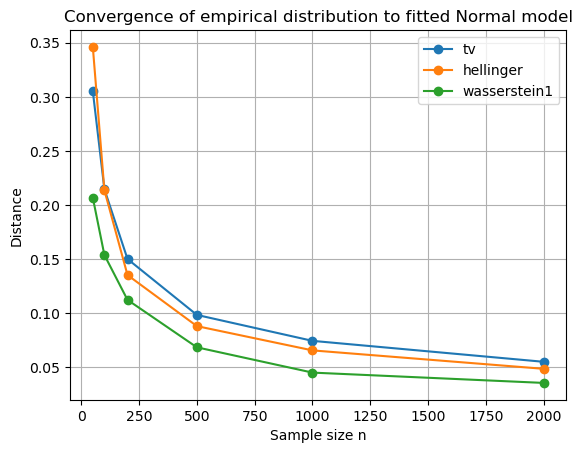

In [28]:
for d in ['tv', 'hellinger', 'wasserstein1']:
    plt.plot(ns, [lc[n][d] for n in ns], marker='o', label=d)

plt.xlabel("Sample size n")
plt.ylabel("Distance")
plt.title("Convergence of empirical distribution to fitted Normal model")
plt.legend()
plt.grid(True)
plt.show()


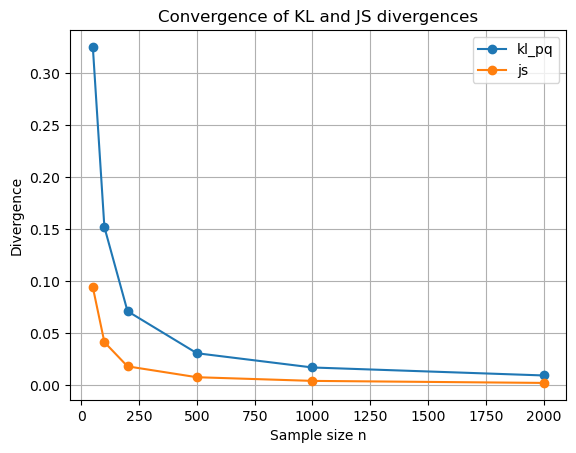

In [29]:
for d in ['kl_pq', 'js']:
    plt.plot(ns, [lc[n][d] for n in ns], marker='o', label=d)

plt.xlabel("Sample size n")
plt.ylabel("Divergence")
plt.title("Convergence of KL and JS divergences")
plt.legend()
plt.grid(True)
plt.show()


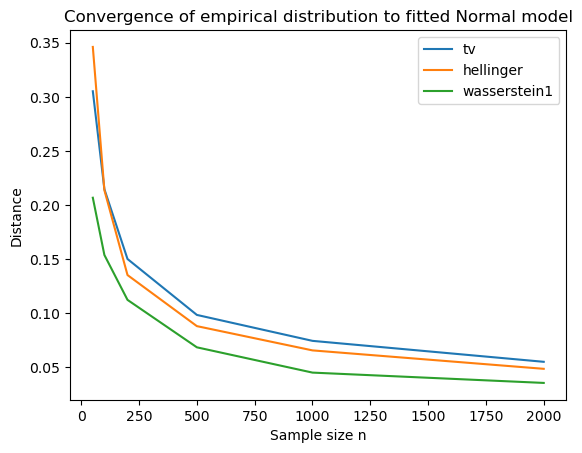

In [30]:
import matplotlib.pyplot as plt

for d in ['tv', 'hellinger', 'wasserstein1']:
    plt.plot(ns, [lc[n][d] for n in ns], label=d)

plt.xlabel("Sample size n")
plt.ylabel("Distance")
plt.legend()
plt.title("Convergence of empirical distribution to fitted Normal model")
plt.show()


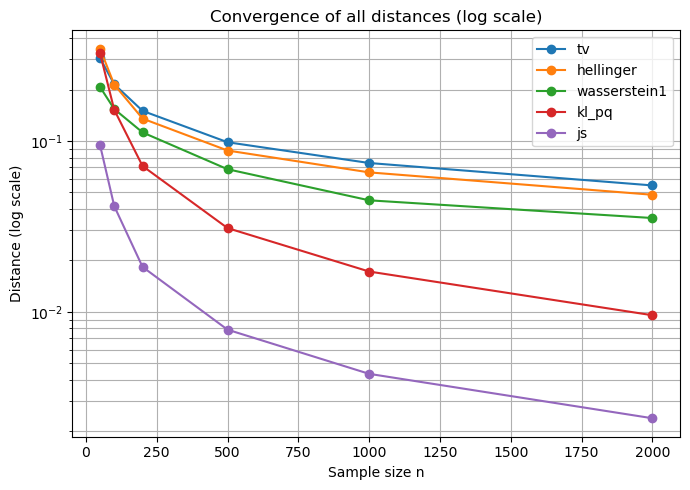

In [31]:
plt.figure(figsize=(7, 5))
for d in ["tv", "hellinger", "wasserstein1", "kl_pq", "js"]:
    plt.plot(ns, [lc[n][d] for n in ns], marker="o", label=d)

plt.xlabel("Sample size n")
plt.ylabel("Distance (log scale)")
plt.yscale("log")
plt.title("Convergence of all distances (log scale)")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


In [34]:
x_miss = np.concatenate([
    np.random.normal(-2, 1, 2500),
    np.random.normal(2, 1, 2500)
])


In [39]:
dist_miss = fit_normal(x_miss)

res_miss = compute_distances(x_miss, dist_miss)
print(res_miss)


DistanceResult(tv=0.24873333174760007, hellinger=0.2113675306465453, js=0.043885272884924664, kl_pq=0.16709493693544733, wasserstein1=0.4334159375863179)
